# XGBoost Classifier
This notebook trains an XGBoost model on the KKBox churn dataset. XGBoost is a gradient boosting algorithm that outperforms Random Forest on tabular data. It handles imbalance via scale_pos_weight.

## 1. Load final dataset

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

#Loading the dataset 
df = pd.read_csv(r"C:\Users\krish\Downloads\kkbox_dataset.csv")
print("Shape:", df.shape)
print(df.head())

Shape: (970960, 52)
                                           msno  is_churn first_transaction_x  \
0  ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=         1                 NaN   
1  f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=         1          2017-03-11   
2  zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=         1          2017-03-11   
3  8iF/+8HY8lJKFrTc7iR9ZYGCG2Ecrogbc2Vy5YhsfhQ=         1          2015-08-08   
4  K6fja4+jmoZ5xG6BypqX80Uw/XKpMgrEMdG2edFOxnA=         1          2016-10-01   

  last_transaction_x last_expire_x  num_transactions  renewal_frequency  \
0                NaN           NaN               NaN                NaN   
1         2017-03-11    2017-04-11               1.0                0.0   
2         2017-03-14    2017-06-15               2.0                0.0   
3         2015-12-08    2018-01-08              10.0                1.0   
4         2017-03-16    2017-09-18               8.0                1.0   

   cancel_frequency  avg_plan_days  avg_li

# 2. Basic Checks

In [2]:
#Checking number of rows and columns, datatypes, etc. 
print(df.columns.tolist())
print(df["is_churn"].value_counts(dropna=False))
print(df["is_churn"].value_counts(normalize=True, dropna=False))

['msno', 'is_churn', 'first_transaction_x', 'last_transaction_x', 'last_expire_x', 'num_transactions', 'renewal_frequency', 'cancel_frequency', 'avg_plan_days', 'avg_list_price', 'avg_amount_paid', 'avg_subscription_length', 'total_subscription_length', 'last_payment_method', 'discount_rate', 'ever_cancelled', 'total_listening_time', 'avg_daily_usage', 'total_unique_songs', 'total_sessions', 'num_log_days', 'last_log_date_x', 'num_25_sum', 'num_100_sum', 'skip_rate', 'completion_rate', 'first_transaction_y', 'last_transaction_y', 'last_expire_y', 'registration_init_time_x', 'last_log_date_y', 'membership_duration', 'days_since_last_transaction', 'time_until_expiration', 'account_age_days_x', 'days_since_last_log', 'duration', 'event_observed', 'city', 'bd', 'gender', 'registered_via', 'registration_init_time_y', 'age', 'registration_year', 'registration_month', 'registration_missing', 'age_group', 'city_tier', 'is_city_1', 'account_age_days_y', 'account_age_group']
is_churn
0    883630

## 3. Define features and target

In [3]:
#Defining target variable y and feature set X
#'is_churn' is the label to be predicted
#'msno' is the user identifier

X = df.drop(columns=["is_churn", "msno"], errors="ignore").copy()
y = df["is_churn"].copy()

print("Initial X shape:", X.shape)
print("Initial y shape:", y.shape)

Initial X shape: (970960, 50)
Initial y shape: (970960,)


## 4. Handle missing values

In [ ]:
#Check for missing values in the dataset

print("Missing values before fill:", X.isnull().sum().sum())
print(X.isnull().sum().sort_values(ascending=False).head(20))

#Fill numerical missing values with median (robust to outliers) and categorical missing values with 'Unknown'
df.fillna(df.median(numeric_only=True), inplace=True)

for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        X[col] = X[col].fillna(X[col].median())
    else:
        X[col] = X[col].fillna("Unknown")

print("Missing values after fill:", X.isnull().sum().sum())

Missing values before fill: 5975180
bd                          584459
days_since_last_log         245744
last_log_date_y             245744
total_unique_songs          216409
completion_rate             216409
skip_rate                   216409
num_log_days                216409
total_sessions              216409
avg_daily_usage             216409
num_100_sum                 216409
last_log_date_x             216409
num_25_sum                  216409
total_listening_time        216409
event_observed              213315
registration_init_time_x    146213
account_age_days_x          146213
account_age_group           109994
account_age_days_y          109994
age_group                   109993
age                         109993
dtype: int64
Missing values after fill: 0


## 5. Encode categorical variables

In [5]:
#Convert categorical variables into numerical format 

from sklearn.preprocessing import LabelEncoder

cat_cols = X.select_dtypes(include="object").columns
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

print("Shape after encoding:", X.shape)
X.head()

Shape after encoding: (970960, 50)


,first_transaction_x,last_transaction_x,last_expire_x,num_transactions,renewal_frequency,cancel_frequency,avg_plan_days,avg_list_price,avg_amount_paid,avg_subscription_length,...,registration_init_time_y,age,registration_year,registration_month,registration_missing,age_group,city_tier,is_city_1,account_age_days_y,account_age_group
0,768,394,1046,1.0,1.0,0.000,30.0,149.0,149.0,31.000,...,3553,28.0,2013.0,12.0,0.0,0,0,0.0,1194.0,4
1,747,373,42,1.0,0.0,0.000,30.0,180.0,180.0,31.000,...,3553,20.0,2013.0,12.0,0.0,5,0,0.0,1194.0,4
2,747,376,107,2.0,0.0,0.000,75.0,150.0,150.0,48.000,...,3557,18.0,2013.0,12.0,0.0,3,0,0.0,1190.0,4
3,205,48,314,10.0,1.0,0.000,30.0,149.0,149.0,685.100,...,3570,27.0,2014.0,1.0,0.0,0,0,1.0,1177.0,4
4,586,378,202,8.0,1.0,0.125,30.0,99.0,99.0,181.375,...,3586,35.0,2014.0,1.0,0.0,0,0,0.0,1161.0,4


## 6. Train-test split

In [6]:
#Splitting the data into training and testing sets
#Stratify ensures class distribution is preserved
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (776768, 50)
X_test: (194192, 50)


## 7. Train XGBoost

In [7]:
#scale_pos_weight handles class imbalance
#learning_rate=0.05 with 300 trees gives a careful boosting approach
#max_depth=4 keeps trees shallow to avoid overfitting

from xgboost import XGBClassifier

#Calculate class imbalance ratio for scale_pos_weight
neg, pos = y_train.value_counts()[0], y_train.value_counts()[1]
print(f"Negative samples: {neg}, Positive samples: {pos}, Ratio: {neg/pos:.2f}")

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    scale_pos_weight=neg / pos,
    eval_metric="logloss",
    use_label_encoder=False
)

xgb_model.fit(X_train, y_train)
print("XGBoost model trained successfully.")

Negative samples: 706904, Positive samples: 69864, Ratio: 10.12


C:\Users\krish\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:200: UserWarning: [20:54:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost model trained successfully.


## 8. Evaluate model

In [8]:
#Evaluating model performance using classification metrics
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score

#Predict class labels and probabilities on test set
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

print("XGBOOST RESULTS")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:", confusion_matrix(y_test, y_pred))

XGBOOST RESULTS
Accuracy: 0.9757
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    176726
           1       0.80      0.97      0.88     17466

    accuracy                           0.98    194192
   macro avg       0.90      0.97      0.93    194192
weighted avg       0.98      0.98      0.98    194192

ROC-AUC: 0.9955553836220018
Confusion Matrix: [[172453   4273]
 [   453  17013]]


## 9. Top features


In [9]:
#Extract feature importances from the trained XGBoost model
#Higher importance = feature used more frequently in tree splits

feature_imp = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
top_features = feature_imp.sort_values(ascending=False)

print("Top 10 Features:")
print(top_features.head(10))

Top 10 Features:
cancel_frequency             0.322302
last_expire_x                0.235338
renewal_frequency            0.075440
total_subscription_length    0.072366
first_transaction_x          0.040853
last_transaction_x           0.039573
discount_rate                0.036677
avg_amount_paid              0.030008
avg_subscription_length      0.027314
avg_list_price               0.016897
dtype: float32


**Confusion Matrix Plot**

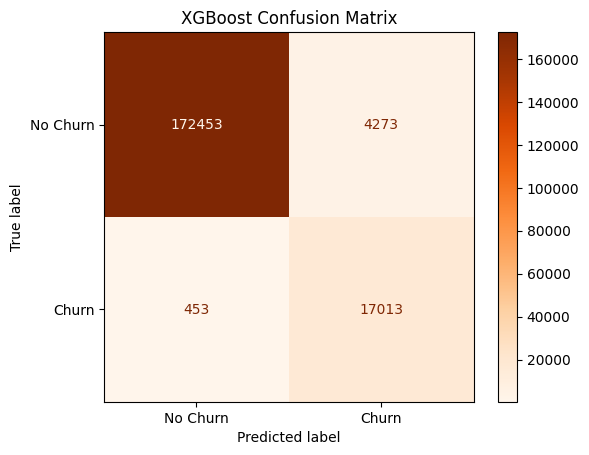

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
disp.plot(cmap="Oranges")
plt.title("XGBoost Confusion Matrix")
plt.show()

**ROC Curve Plot**

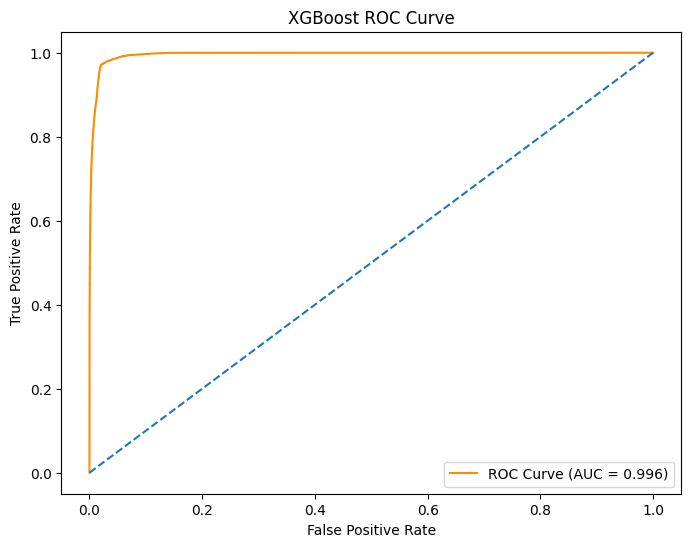

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")
plt.legend()
plt.show()

**Top 15 Feature Importances Plot**

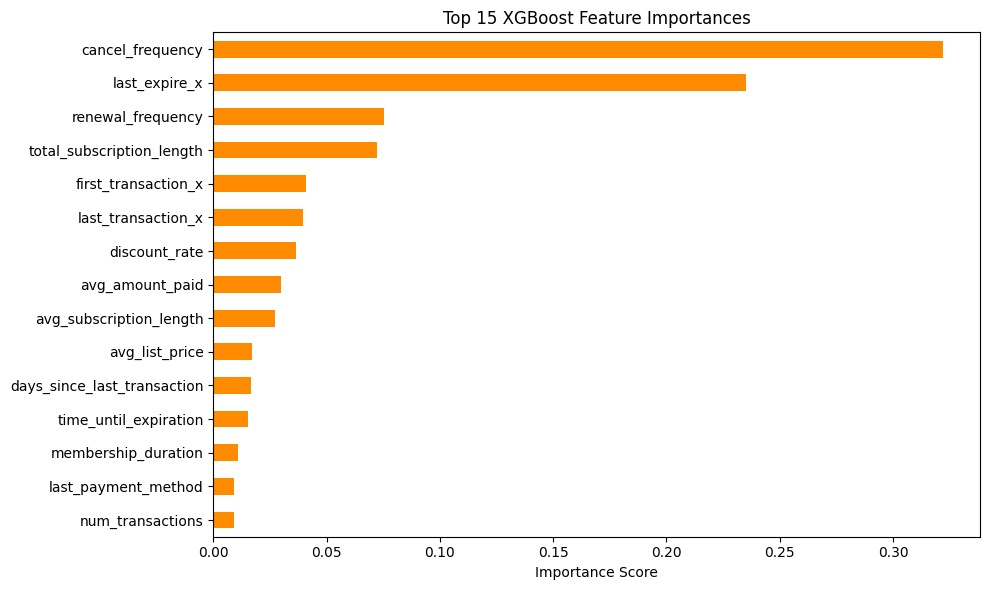

In [12]:
import matplotlib.pyplot as plt

top15 = feature_imp.sort_values(ascending=False).head(15).sort_values()

plt.figure(figsize=(10, 6))
top15.plot(kind="barh", color="darkorange")
plt.xlabel("Importance Score")
plt.title("Top 15 XGBoost Feature Importances")
plt.tight_layout()
plt.show()

## Insights

~ XGBoost often achieves higher ROC-AUC than Logistic Regression and Random Forest on tabular data. 

~ scale_pos_weight directly addresses the churn class imbalance during training.